## WEEK 3-4 - End-to-End Sales Forecasting & Demand Intelligence System


## Task 1
Lets first load and analyze the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("data.csv")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (9800, 18)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:

df.info()

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

The 11 columns in postal code wont make much difference in forecasting ..

In [5]:

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

print(df[["Order Date", "Ship Date"]].dtypes)
print("Order date range:", df["Order Date"].min(), "to", df["Order Date"].max())

ValueError: time data "15/04/2018" doesn't match format "%m/%d/%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

Lets make it day first 

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

print(df[["Order Date", "Ship Date"]].dtypes)
print("Order date range:", df["Order Date"].min(), "to", df["Order Date"].max())

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object
Order date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


Time based classification

In [7]:

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Month_Name"] = df["Order Date"].dt.month_name()
df["Week_Number"] = df["Order Date"].dt.isocalendar().week.astype(int)  # extra from internet 
df["Day_of_Week"] = df["Order Date"].dt.day_name()
df["Quarter"] = df["Order Date"].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"    # suggestion from internet 

df["Season"] = df["Month"].apply(get_season)

df[["Order Date", "Year", "Month", "Month_Name", "Week_Number", "Day_of_Week", "Quarter", "Season"]].head()

,Order Date,Year,Month,Month_Name,Week_Number,Day_of_Week,Quarter,Season
0,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
1,2017-11-08,2017,11,November,45,Wednesday,4,Autumn
2,2017-06-12,2017,6,June,24,Monday,2,Summer
3,2016-10-11,2016,10,October,41,Tuesday,4,Autumn
4,2016-10-11,2016,10,October,41,Tuesday,4,Autumn


In [ ]:

df["Shipping_Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping_Days"]].head()

,Order Date,Ship Date,Shipping_Days
0,2017-11-08,2017-11-11,3
1,2017-11-08,2017-11-11,3
2,2017-06-12,2017-06-16,4
3,2016-10-11,2016-10-18,7
4,2016-10-11,2016-10-18,7


Segregation

In [12]:

daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()
daily_sales = daily_sales.sort_values("Order Date")
weekly_sales = df.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"].sum().reset_index()
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().reset_index()

print("Daily sales shape:", daily_sales.shape)
print("Weekly sales shape:", weekly_sales.shape)
print("Monthly sales shape:", monthly_sales.shape)

display(daily_sales.head())
display(weekly_sales.head())
display(monthly_sales.head())

Daily sales shape: (1230, 2)
Weekly sales shape: (209, 2)
Monthly sales shape: (48, 2)


,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Data segregration done daily weekly and monthly 

In [13]:

category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


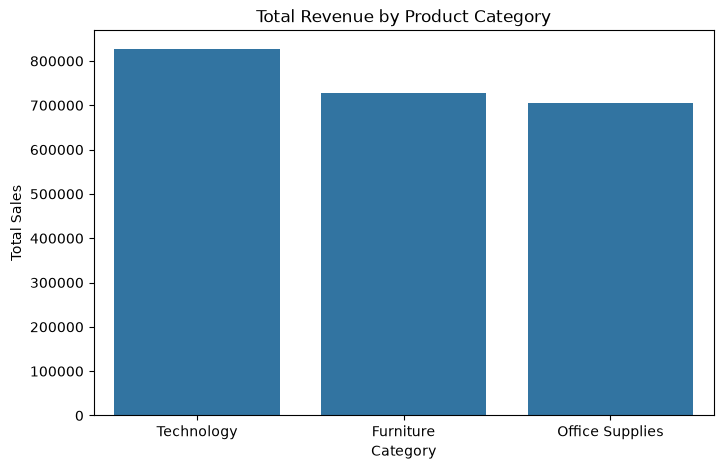

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

Which product category generates the highest total revenue? - Technology 

In [15]:
region_year_sales = df.groupby(["Year", "Region"])["Sales"].sum().reset_index()
region_year_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


In [ ]:
region_year_pivot = region_year_sales.pivot(index="Year", columns="Region", values="Sales")  # sourced from internet 
region_year_pivot

Region,Central,East,South,West
Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,153225.183,70076.0825,133709.5675
2017,145673.8800,178511.538,93535.9035,182471.2285
2018,141627.3402,210129.186,122164.5675,248130.9255


So as we can see 
* East: Shows the most consistent upward trend, with sales increasing steadily across all four years and no visible decline.
* West: Shows strong overall growth and ends with the highest sales in the final year, but the trend is less consistent because of a dip in 2016 before rising again.
* Central: Remains relatively stable in the first two years, grows in 2017, and then slightly drops in 2018, so the trend is not consistently upward.
* South: sharp drop after 2015 followed by recovery in later years.

Which region has the most consistent sales growth over 4 years? - East 

In [17]:
region_shipping = df.groupby("Region")["Shipping_Days"].mean().sort_values()
region_shipping

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64

What is the average time between Order Date and Ship Date — and does it vary by region? - Nope as u can see its almost uniform every region .. Average of about 4 days 

In [18]:
monthly_pattern = df.groupby(["Year", "Month_Name"])["Sales"].sum().reset_index()

month_order = ["January", "February", "March", "April", "May", "June","July", "August", "September", "October", "November", "December"]

monthly_pattern["Month_Name"] = pd.Categorical(
    monthly_pattern["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_pattern = monthly_pattern.sort_values(["Year", "Month_Name"])
monthly_pattern.head(12)

,Year,Month_Name,Sales
4,2015,January,14205.7070
3,2015,February,4519.8920
7,2015,March,55205.7970
0,2015,April,27906.8550
8,2015,May,23644.3030
6,2015,June,34322.9356
5,2015,July,33781.5430
1,2015,August,27117.5365
11,2015,September,81623.5268
10,2015,October,31453.3930


In [19]:
monthly_pivot = monthly_pattern.pivot(index="Month_Name", columns="Year", values="Sales")
monthly_pivot

Year,2015,2016,2017,2018
Month_Name,,,,
January,14205.7070,18066.9576,18542.4910,43476.4740
February,4519.8920,11951.4110,22978.8150,19920.9974
March,55205.7970,32339.3184,51165.0590,58863.4128
April,27906.8550,34154.4685,38679.7670,35541.9101
May,23644.3030,29959.5305,56656.9080,43825.9822
June,34322.9356,23599.3740,39724.4860,48190.7277
July,33781.5430,28608.2590,38320.7830,44825.1040
August,27117.5365,36818.3422,30542.2003,62837.8480
September,81623.5268,63133.6060,69193.3909,86152.8880


As we can see November and December shows the most consistent spikes across all years 

In [20]:
daily_sales.to_csv("daily_sales.csv", index=False)
weekly_sales.to_csv("weekly_sales.csv", index=False)
monthly_sales.to_csv("monthly_sales.csv", index=False)

Task 1 Summary
* The dataset was cleaned and prepared for time-series analysis by converting date columns and generating temporal features such as year, month, week number, quarter, and season.
* Sales were aggregated at daily, weekly, and monthly levels to support downstream forecasting and anomaly detection tasks.
* Technology generated the highest total revenue among all product categories.
* The East region showed the most consistent sales growth over the four-year period.
* Shipping time varied slightly across regions, which may reflect regional logistics differences.
* Monthly sales patterns suggest seasonality, with November and December showing repeated sales spikes across years.

## Task 2


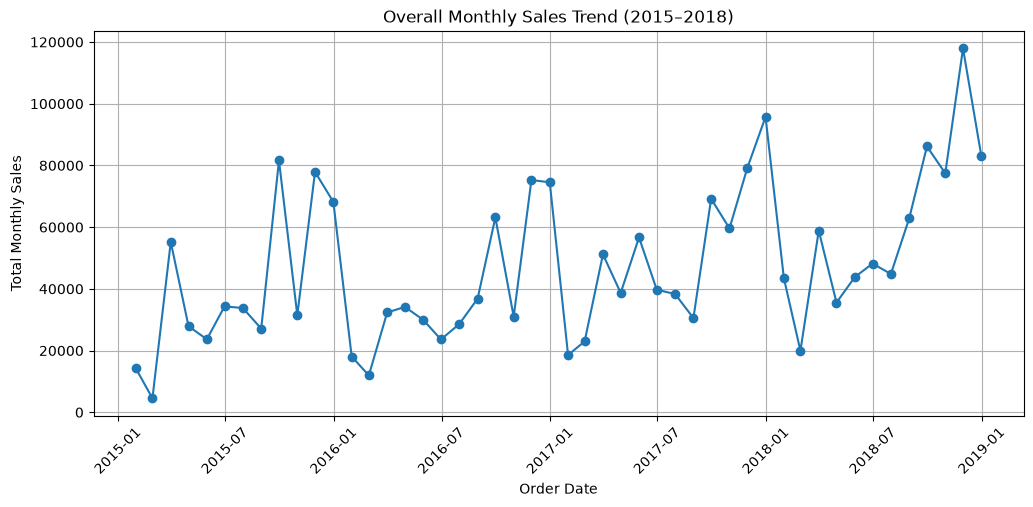

In [23]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller


plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], marker="o")
plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Order Date")
plt.ylabel("Total Monthly Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

Monthly sales patterns suggest seasonality, with several high-sales periods recurring across years. November and December often show strong sales, but the overall monthly trend also indicates that some major peaks occur around the beginning of the year in certain years. This suggests that seasonality exists, though the exact peak month is not perfectly uniform across all four years.

Time series Decomposition 

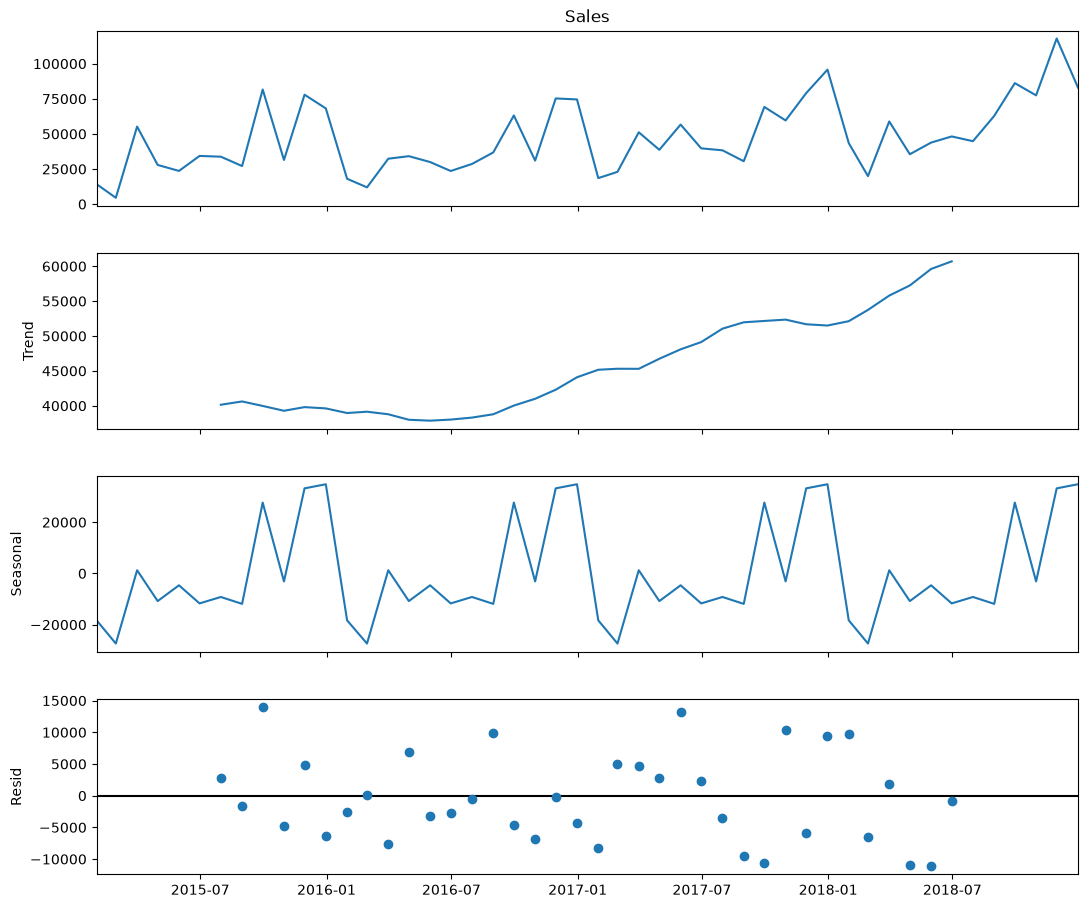

In [24]:
monthly_ts = monthly_sales.set_index("Order Date")["Sales"]
decomposition = seasonal_decompose(monthly_ts, model="additive", period=12)
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

Decomposition observations
* The trend component shows that overall sales increase over time, especially from mid-2016 onward, indicating long-term business growth.
* The seasonal component displays a repeating yearly pattern, suggesting that monthly sales are influenced by recurring seasonal effects rather      than being purely random.
* The observed sales series contains several sharp peaks and dips, but decomposition shows that part of this variation comes from underlying trend and seasonal structure.
* The residual component still contains noticeable fluctuations, meaning some months experience unusual sales behavior that cannot be fully explained by long-term growth and seasonality alone.

In [ ]:
residual_df = decomposition.resid.dropna().reset_index()
residual_df.columns = ["Order Date", "Residual"]

# Add absolute residual to find strongest noise months
residual_df["Abs_Residual"] = residual_df["Residual"].abs()

top_residual_months = residual_df.sort_values("Abs_Residual", ascending=False).head(5)
top_residual_months

#used ai help in this region 

,Order Date,Residual,Abs_Residual
2,2015-09-30,13970.933082,13970.933082
22,2017-05-31,13193.079793,13193.079793
34,2018-05-31,-11157.549320,11157.549320
33,2018-04-30,-10916.959724,10916.959724
26,2017-09-30,-10642.715643,10642.715643


From the decomposition residuals, the months with the strongest unexplained deviations are:

September 2015 → strongest positive residual noise
May 2017 → another strong positive residual spike
April 2018 and May 2018 → strong negative residual noise
September 2017 → another notable negative residual month

In [26]:
adf_result = adfuller(monthly_ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations used:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Number of lags used: 0
Number of observations used: 47

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


* Here p value is < 0.05 , thus we can infer it is stationary ... 
Stationary means the after considering factors like avg level and variance , the entity remains stable .. 

* The Augmented Dickey-Fuller (ADF) test was applied to the monthly sales series to check whether it is stationary. The test produced a p-value of 0.000278, which is lower than the significance threshold of 0.05. Therefore, the null hypothesis of non-stationarity is rejected. This suggests that the monthly sales series can be treated as stationary, so differencing was not required at this stage.

Differencing decision

Differencing is typically applied when a time series is non-stationary and needs to be stabilized before modeling.Since the ADF test indicated that the monthly sales series is already stationary, differencing was not applied. The original monthly series was retained for the forecasting tasks.

## Task 2 Summary
* The monthly sales series shows an overall upward trend, especially from the later part of the dataset, indicating long-term business growth.
* Time series decomposition reveals a clear seasonal pattern, suggesting that monthly sales are influenced by recurring yearly effects.
* Residual analysis shows that some months still experience unusually high or low sales even after removing trend and seasonality, indicating the presence of irregular noise.
* The ADF test was used to check stationarity, using a significance threshold of 0.05.
Since the p-value obtained (0.000278) is lower than 0.05, the monthly sales series was treated as stationary and differencing was not applied.